In [ ]:
import yfinance as yf
import pandas as pd

# Define stock ticker and time intervals
ticker = "NVDA"  # Example: Apple Inc.
interval = "1m"  # 1-minute interval

# Define start and end dates for the first 7-day period
start_date_1 = "2025-03-31"
end_date_1 = "2025-04-04"

# Fetch first 7-day minute-level data
data_7_days_1 = yf.download(ticker, start=start_date_1, end=end_date_1, interval=interval)
data_7_days_1 = data_7_days_1[['Close']].dropna()

# Define start and end dates for the next 7-day period
start_date_2 = "2025-04-07"
end_date_2 = "2025-04-11"

# Fetch next 7-day minute-level data
data_7_days_2 = yf.download(ticker, start=start_date_2, end=end_date_2, interval=interval)
data_7_days_2 = data_7_days_2[['Close']].dropna()

# Define the start and nd dates for the next 3 days period
start_date_3 = "2025-04-14"
end_date_3 = "2025-04-18"

# Fetch next 7-day minute-level data
data_7_days_3 = yf.download(ticker, start=start_date_3, end=end_date_3, interval=interval)
data_7_days_3 = data_7_days_3[['Close']].dropna()

print("First 7-Day Data:")
print(data_7_days_1.head())

print("\nNext 7-Day Data:")
print(data_7_days_2.head())

print("\nNext 7-Day Data:")
print(data_7_days_3.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

First 7-Day Data:
Price                           Close
Ticker                           NVDA
Datetime                             
2025-03-31 13:30:00+00:00  105.695000
2025-03-31 13:31:00+00:00  105.070198
2025-03-31 13:32:00+00:00  105.250000
2025-03-31 13:33:00+00:00  104.570000
2025-03-31 13:34:00+00:00  104.489998

Next 7-Day Data:
Price                          Close
Ticker                          NVDA
Datetime                            
2025-04-07 13:30:00+00:00  88.224998
2025-04-07 13:31:00+00:00  88.885002
2025-04-07 13:32:00+00:00  87.889000
2025-04-07 13:33:00+00:00  88.409698
2025-04-07 13:34:00+00:00  88.220001

Next 7-Day Data:
Price                           Close
Ticker                           NVDA
Datetime                             
2025-04-14 13:30:00+00:00  113.900002
2025-04-14 13:31:00+00:00  113.154999
2025-04-14 13:32:00+00:00  113.500000
2025-04-14 13:33:00+00:00  112.875000
2025-04-14 13:34:00+00:00  113.110603


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Combine both datasets for preprocessing
data_combined = pd.concat([data_7_days_1, data_7_days_2, data_7_days_3])

# Scale the data
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(data_combined['Close'].values.reshape(-1, 1))

# Define sequence length
SEQ_LENGTH = 60

# Create input sequences and actual prices
X_for_prediction = np.array([scaled_prices[i:i + SEQ_LENGTH] for i in range(len(scaled_prices) - SEQ_LENGTH)])
y_for_prediction = scaled_prices[SEQ_LENGTH:].flatten()

# Reshape X_for_prediction for model input
X_for_prediction = X_for_prediction.reshape(-1, SEQ_LENGTH, 1)

In [ ]:
!pip install optuna

In [ ]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Function to optimize CNN-LSTM with Optuna
def optimize_cnn_lstm(trial):
    filters = trial.suggest_int('filters', 32, 128)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    lstm_units = trial.suggest_int('lstm_units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=(SEQ_LENGTH, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(lstm_units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_for_prediction, y_for_prediction, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    val_loss = model.evaluate(X_for_prediction, y_for_prediction, verbose=0)
    return val_loss

# Run Optuna optimization
study_cnn_lstm = optuna.create_study(direction='minimize')
study_cnn_lstm.optimize(optimize_cnn_lstm, n_trials=10)

# Best parameters for CNN-LSTM
cnn_lstm_best_params = study_cnn_lstm.best_params
print("Best CNN-LSTM Params:", cnn_lstm_best_params)

[I 2025-04-22 10:31:46,940] A new study created in memory with name: no-name-99d3ff52-88b8-48d7-b381-8aa36df28748
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-04-22 10:32:10,126] Trial 0 finished with value: 0.0005419165827333927 and parameters: {'filters': 51, 'kernel_size': 2, 'lstm_units': 201, 'dropout_rate': 0.3026194041518871}. Best is trial 0 with value: 0.0005419165827333927.
[I 2025-04-22 10:32:23,029] Trial 1 finished with value: 0.0006137015880085528 and parameters: {'filters': 112, 'kernel_size': 5, 'lstm_units': 110, 'dropout_rate': 0.4871592783019698}. Best is trial 0 with value: 0.0005419165827333927.
[I 2025-04-22 10:32:35,726] Trial 2 finished with value: 0.000332932

Best CNN-LSTM Params: {'filters': 120, 'kernel_size': 3, 'lstm_units': 229, 'dropout_rate': 0.15825178501015513}


In [ ]:
# Build and train CNN-LSTM model with best parameters
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=cnn_lstm_best_params['filters'],
                          kernel_size=cnn_lstm_best_params['kernel_size'],
                          activation='relu', input_shape=(SEQ_LENGTH, 1)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))
cnn_lstm_model.add(LSTM(cnn_lstm_best_params['lstm_units'], return_sequences=False))
cnn_lstm_model.add(Dropout(cnn_lstm_best_params['dropout_rate']))
cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.fit(X_for_prediction, y_for_prediction, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0350 - val_loss: 3.4470e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 2.4106e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 2.3482e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.7209e-04 - val_loss: 2.3322e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - val_loss: 1.4075e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 1.3021e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 2.7683e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.2482e-04 - val_loss: 1.8040e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6122e-04 - val_loss: 1.4272e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.4833e-04 - val_loss: 2.5863e-04
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7349e-04 - val_loss:

In [ ]:
# Define start and end dates for the 15th day
start_date_4 = "2025-04-21"
end_date_4 = "2025-04-22"

# Fetch 15th day minute-level data
data_15th = yf.download(ticker, start=start_date_4, end=end_date_4, interval=interval)
data_15th = data_15th[['Close']].dropna()

# Get the scaled prices for the 15th day
scaled_prices_15th = scaler.transform(data_15th['Close'].values.reshape(-1, 1))


[*********************100%***********************]  1 of 1 completed


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Generate predictions for every timestep in data_15th
cnn_lstm_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
    pred_scaled = cnn_lstm_model.predict(current_sequence)
    cnn_lstm_preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

# Inverse transform to get the actual predicted prices
cnn_lstm_preds = scaler.inverse_transform(np.array(cnn_lstm_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, cnn_lstm_preds)
rmse = np.sqrt(mean_squared_error(real_price, cnn_lstm_preds))
r2 = r2_score(real_price, cnn_lstm_preds)

# Modify Adjusted R-squared calculation
n = len(real_price) # Number of data points
p = 1 # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
  adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
  adjusted_r2 = np.nan  # or 0, or another suitable value
  print("Warning: Adjusted R-squared is undefined due to insufficient data points.")


accuracy = 1 - np.mean(np.abs(cnn_lstm_preds - real_price) / real_price)

print(f"CNN-LSTM Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Function to optimize Conv1D with Optuna
def optimize_conv1d(trial):
    filters = trial.suggest_int('filters', 32, 128)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dense_units = trial.suggest_int('dense_units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=(SEQ_LENGTH, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_for_prediction, y_for_prediction, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    val_loss = model.evaluate(X_for_prediction, y_for_prediction, verbose=0)
    return val_loss

# Run Optuna optimization
study_conv1d = optuna.create_study(direction='minimize')
study_conv1d.optimize(optimize_conv1d, n_trials=10)

# Best parameters for Conv1D
conv1d_best_params = study_conv1d.best_params
print("Best Conv1D Params:", conv1d_best_params)

[I 2025-04-22 10:35:10,301] A new study created in memory with name: no-name-b487e866-c56b-4bae-b551-c1cb20e18562
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-04-22 10:35:21,794] Trial 0 finished with value: 0.0005817885394208133 and parameters: {'filters': 125, 'kernel_size': 2, 'dense_units': 234, 'dropout_rate': 0.1179614338000528}. Best is trial 0 with value: 0.0005817885394208133.
[I 2025-04-22 10:35:31,532] Trial 1 finished with value: 0.0006303985137492418 and parameters: {'filters': 94, 'kernel_size': 2, 'dense_units': 233, 'dropout_rate': 0.17704220540030224}. Best is trial 0 with value: 0.0005817885394208133.
[I 2025-04-22 10:35:43,601] Trial 2 finished with value: 0.000485

Best Conv1D Params: {'filters': 73, 'kernel_size': 3, 'dense_units': 193, 'dropout_rate': 0.10393171812444534}


In [ ]:
# Build and train Conv1D model with best parameters
conv1d_model = Sequential()
conv1d_model.add(Conv1D(filters=conv1d_best_params['filters'],
                        kernel_size=conv1d_best_params['kernel_size'],
                        activation='relu', input_shape=(SEQ_LENGTH, 1)))
conv1d_model.add(MaxPooling1D(pool_size=2))
conv1d_model.add(Flatten())
conv1d_model.add(Dense(conv1d_best_params['dense_units'], activation='relu'))
conv1d_model.add(Dropout(conv1d_best_params['dropout_rate']))
conv1d_model.add(Dense(1))
conv1d_model.compile(optimizer='adam', loss='mse')
conv1d_model.fit(X_for_prediction, y_for_prediction, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0460 - val_loss: 9.3620e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0030 - val_loss: 6.9264e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023 - val_loss: 2.2818e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0020 - val_loss: 3.1325e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 4.5040e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - val_loss: 2.0598e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - val_loss: 1.5105e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0015 - val_loss: 3.7925e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 8.7911e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - val_loss: 1.4987e-04
Epoch 12/20

In [ ]:
# Generate predictions for every timestep in data_15th
conv1d_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
    pred_scaled = conv1d_model.predict(current_sequence)
    conv1d_preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

# Inverse transform to get the actual predicted prices
conv1d_preds = scaler.inverse_transform(np.array(conv1d_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, conv1d_preds)
rmse = np.sqrt(mean_squared_error(real_price, conv1d_preds))
r2 = r2_score(real_price, conv1d_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(conv1d_preds - real_price) / real_price)

print(f"Conv1D Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

In [ ]:
from tensorflow.keras.layers import Bidirectional

# Function to optimize BiLSTM with Optuna
def optimize_bilstm(trial):
    units = trial.suggest_int('units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    model = Sequential()
    model.add(Bidirectional(LSTM(units, return_sequences=True), input_shape=(SEQ_LENGTH, 1)))
    model.add(Dropout(dropout_rate))
    model.add(Bidirectional(LSTM(units // 2, return_sequences=False)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_for_prediction, y_for_prediction, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    val_loss = model.evaluate(X_for_prediction, y_for_prediction, verbose=0)
    return val_loss

# Run Optuna optimization
study_bilstm = optuna.create_study(direction='minimize')
study_bilstm.optimize(optimize_bilstm, n_trials=10)

# Best parameters for BiLSTM
bilstm_best_params = study_bilstm.best_params
print("Best BiLSTM Params:", bilstm_best_params)

[I 2025-04-22 10:38:55,542] A new study created in memory with name: no-name-bd3b81e5-0031-4cc1-8135-4ee9f61477f8
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-04-22 10:39:22,853] Trial 0 finished with value: 0.0005687811644747853 and parameters: {'units': 121, 'dropout_rate': 0.44954150685129146}. Best is trial 0 with value: 0.0005687811644747853.
[I 2025-04-22 10:39:52,297] Trial 1 finished with value: 0.0003481877502053976 and parameters: {'units': 182, 'dropout_rate': 0.24900410295611422}. Best is trial 1 with value: 0.0003481877502053976.
[I 2025-04-22 10:40:21,239] Trial 2 finished with value: 0.00033579402952454984 and parameters: {'units': 235, 'dropout_rate': 0.33051972141599273}. Best is trial 2 with value: 0.0003357940295

Best BiLSTM Params: {'units': 235, 'dropout_rate': 0.33051972141599273}


In [ ]:
# Build and train BiLSTM model with best parameters
bilstm_model = Sequential()
bilstm_model.add(Bidirectional(LSTM(bilstm_best_params['units'], return_sequences=True), input_shape=(SEQ_LENGTH, 1)))
bilstm_model.add(Dropout(bilstm_best_params['dropout_rate']))
bilstm_model.add(Bidirectional(LSTM(bilstm_best_params['units'] // 2, return_sequences=False)))
bilstm_model.add(Dense(1))
bilstm_model.compile(optimizer='adam', loss='mse')
bilstm_model.fit(X_for_prediction, y_for_prediction, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0355 - val_loss: 6.3293e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0013 - val_loss: 2.9879e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.2383e-04 - val_loss: 2.8498e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 6.7035e-04 - val_loss: 2.0261e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 6.3208e-04 - val_loss: 3.7932e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5.8277e-04 - val_loss: 1.8472e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.0409e-04 - val_loss: 2.7156e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 7.5796e-04 - val_loss: 1.6965e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 5.7171e-04 - val_loss: 2.2533e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 5.5713e-04 - val_loss: 1.4602e-04
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - l

In [ ]:
# Generate predictions for every timestep in data_15th
bilstm_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
    pred_scaled = bilstm_model.predict(current_sequence)
    bilstm_preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

# Inverse transform to get the actual predicted prices
bilstm_preds = scaler.inverse_transform(np.array(bilstm_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, bilstm_preds)
rmse = np.sqrt(mean_squared_error(real_price, bilstm_preds))
r2 = r2_score(real_price, bilstm_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(bilstm_preds - real_price) / real_price)

print(f"BiLSTM Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━

In [ ]:
# Function to optimize Stacked LSTM with Optuna
def optimize_stacked_lstm(trial):
    units = trial.suggest_int('units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_for_prediction, y_for_prediction, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    val_loss = model.evaluate(X_for_prediction, y_for_prediction, verbose=0)
    return val_loss

# Run Optuna optimization
study_stacked_lstm = optuna.create_study(direction='minimize')
study_stacked_lstm.optimize(optimize_stacked_lstm, n_trials=10)

# Best parameters for Stacked LSTM
stacked_lstm_best_params = study_stacked_lstm.best_params
print("Best Stacked LSTM Params:", stacked_lstm_best_params)

[I 2025-04-22 10:45:29,420] A new study created in memory with name: no-name-d4191317-def6-477a-ae09-afc27e96cc20
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-04-22 10:45:46,427] Trial 0 finished with value: 0.0007603466510772705 and parameters: {'units': 154, 'dropout_rate': 0.4476053109598207}. Best is trial 0 with value: 0.0007603466510772705.
[I 2025-04-22 10:46:02,636] Trial 1 finished with value: 0.0006616270402446389 and parameters: {'units': 123, 'dropout_rate': 0.26641572357505106}. Best is trial 1 with value: 0.0006616270402446389.
[I 2025-04-22 10:46:19,481] Trial 2 finished with value: 0.0006750315660610795 and parameters: {'units': 148, 'dropout_rate': 0.44110773041034546}. Best is trial 1 with value: 0.0006616270402446389.
[I 2

Best Stacked LSTM Params: {'units': 237, 'dropout_rate': 0.1640433296891562}


In [ ]:
# Build and train Stacked LSTM model with best parameters
stacked_lstm_model = Sequential()
stacked_lstm_model.add(LSTM(stacked_lstm_best_params['units'], return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
stacked_lstm_model.add(Dropout(stacked_lstm_best_params['dropout_rate']))
stacked_lstm_model.add(LSTM(stacked_lstm_best_params['units'] // 2, return_sequences=False))
stacked_lstm_model.add(Dropout(stacked_lstm_best_params['dropout_rate']))
stacked_lstm_model.add(Dense(1))
stacked_lstm_model.compile(optimizer='adam', loss='mse')
stacked_lstm_model.fit(X_for_prediction, y_for_prediction, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0390 - val_loss: 3.3896e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0025 - val_loss: 5.0422e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0022 - val_loss: 8.1637e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 2.8628e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - val_loss: 3.1118e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 6.6789e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018 - val_loss: 3.5821e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 2.8247e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017 - val_loss: 2.2289e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015 - val_loss: 4.4945e-04
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0017 - val_loss: 1.9576e-

In [ ]:
# Generate predictions for every timestep in data_15th
stacked_lstm_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
    pred_scaled = stacked_lstm_model.predict(current_sequence)
    stacked_lstm_preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

# Inverse transform to get the actual predicted prices
stacked_lstm_preds = scaler.inverse_transform(np.array(stacked_lstm_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, stacked_lstm_preds)
rmse = np.sqrt(mean_squared_error(real_price, stacked_lstm_preds))
r2 = r2_score(real_price, stacked_lstm_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(stacked_lstm_preds - real_price) / real_price)

print(f"Stacked LSTM Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

In [ ]:
from tensorflow.keras.layers import GRU

# Function to optimize GRU with Optuna
def optimize_gru(trial):
    units = trial.suggest_int('units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)

    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_for_prediction, y_for_prediction, epochs=10, batch_size=32, validation_split=0.2, verbose=0)
    val_loss = model.evaluate(X_for_prediction, y_for_prediction, verbose=0)
    return val_loss

# Run Optuna optimization
study_gru = optuna.create_study(direction='minimize')
study_gru.optimize(optimize_gru, n_trials=10)

# Best parameters for GRU
gru_best_params = study_gru.best_params
print("Best GRU Params:", gru_best_params)

[I 2025-04-22 10:49:18,463] A new study created in memory with name: no-name-2b4ff57b-4523-44ab-b282-7251d6d856bd
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-04-22 10:49:33,908] Trial 0 finished with value: 0.00036732692387886345 and parameters: {'units': 185, 'dropout_rate': 0.3752550530506442}. Best is trial 0 with value: 0.00036732692387886345.
[I 2025-04-22 10:49:53,910] Trial 1 finished with value: 0.00033650267869234085 and parameters: {'units': 164, 'dropout_rate': 0.30614291153720674}. Best is trial 1 with value: 0.00033650267869234085.
[I 2025-04-22 10:50:10,658] Trial 2 finished with value: 0.00041842731297947466 and parameters: {'units': 129, 'dropout_rate': 0.37158456237967064}. Best is trial 1 with value: 0.00033650267869234085

Best GRU Params: {'units': 243, 'dropout_rate': 0.16203733053496383}


In [ ]:
# Build and train GRU model with best parameters
gru_model = Sequential()
gru_model.add(GRU(gru_best_params['units'], return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
gru_model.add(Dropout(gru_best_params['dropout_rate']))
gru_model.add(GRU(gru_best_params['units'] // 2, return_sequences=False))
gru_model.add(Dropout(gru_best_params['dropout_rate']))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_for_prediction, y_for_prediction, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0511 - val_loss: 4.5337e-04
Epoch 2/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0021 - val_loss: 1.5749e-04
Epoch 3/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 1.5429e-04
Epoch 4/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 1.4932e-04
Epoch 5/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017 - val_loss: 2.4970e-04
Epoch 6/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016 - val_loss: 1.6778e-04
Epoch 7/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 1.5049e-04
Epoch 8/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0014 - val_loss: 2.6144e-04
Epoch 9/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0015 - val_loss: 5.3518e-04
Epoch 10/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 1.9435e-04
Epoch 11/20
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 2.1583e-04
Epo

In [ ]:
# Generate predictions for every timestep in data_15th
gru_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
    pred_scaled = gru_model.predict(current_sequence)
    gru_preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

# Inverse transform to get the actual predicted prices
gru_preds = scaler.inverse_transform(np.array(gru_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, gru_preds)
rmse = np.sqrt(mean_squared_error(real_price, gru_preds))
r2 = r2_score(real_price, gru_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(gru_preds - real_price) / real_price)

print(f"GRU Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split # Import train_test_split

# Flatten input data for traditional ML models
X_flat = X_for_prediction.reshape(-1, SEQ_LENGTH)

# Split data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_flat, y_for_prediction, test_size=0.2, random_state=42)

In [ ]:
# Function to optimize Random Forest with Optuna
def optimize_random_forest(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 10, 50)

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    val_loss = mean_squared_error(y_val, model.predict(X_val))
    return val_loss

# Run Optuna optimization
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(optimize_random_forest, n_trials=10)

# Best parameters for Random Forest
rf_best_params = study_rf.best_params
print("Best Random Forest Params:", rf_best_params)

[I 2025-04-22 10:53:14,957] A new study created in memory with name: no-name-28abd0e6-e74b-4de4-8430-8d4775edc694
[I 2025-04-22 10:53:28,202] Trial 0 finished with value: 0.00015040577055150544 and parameters: {'n_estimators': 70, 'max_depth': 29}. Best is trial 0 with value: 0.00015040577055150544.
[I 2025-04-22 10:53:59,615] Trial 1 finished with value: 0.00015695732629369776 and parameters: {'n_estimators': 164, 'max_depth': 24}. Best is trial 0 with value: 0.00015040577055150544.
[I 2025-04-22 10:54:13,751] Trial 2 finished with value: 0.0001483199181239891 and parameters: {'n_estimators': 75, 'max_depth': 50}. Best is trial 2 with value: 0.0001483199181239891.
[I 2025-04-22 10:54:34,412] Trial 3 finished with value: 0.00015230114022169177 and parameters: {'n_estimators': 108, 'max_depth': 34}. Best is trial 2 with value: 0.0001483199181239891.
[I 2025-04-22 10:55:01,820] Trial 4 finished with value: 0.00015285296808205485 and parameters: {'n_estimators': 145, 'max_depth': 22}. Bes

Best Random Forest Params: {'n_estimators': 76, 'max_depth': 10}


In [ ]:
# Build and train Random Forest model with best parameters
rf_model = RandomForestRegressor(
    n_estimators=rf_best_params['n_estimators'],
    max_depth=rf_best_params['max_depth'],
    random_state=42
)
rf_model.fit(X_flat, y_for_prediction)

RandomForestRegressor(max_depth=10, n_estimators=76, random_state=42)

In [ ]:
import numpy as np

# Flatten the 15th day data for Random Forest
# Reshape into blocks of 60 rows
num_full_blocks = len(scaled_prices_15th) // SEQ_LENGTH  # Number of full blocks of 60
remaining_rows = len(scaled_prices_15th) % SEQ_LENGTH  # Remaining rows

# Create an array to store the reshaped blocks
scaled_prices_15th_blocks = []

# Reshape full blocks
for i in range(num_full_blocks):
    start_index = i * SEQ_LENGTH
    end_index = start_index + SEQ_LENGTH
    block = scaled_prices_15th[start_index:end_index].reshape(1, -1)  # Reshape to (1, SEQ_LENGTH)
    scaled_prices_15th_blocks.append(block)

# If there are remaining rows, pad them with zeros to reach SEQ_LENGTH
if remaining_rows > 0:
    last_block = scaled_prices_15th[-remaining_rows:].reshape(1, -1)  # Reshape to (1, remaining_rows)
    # Pad with zeros to reach SEQ_LENGTH
    padded_block = np.pad(last_block, ((0, 0), (0, SEQ_LENGTH - remaining_rows)), 'constant', constant_values=0)
    scaled_prices_15th_blocks.append(padded_block)

# Concatenate all blocks into a single array
scaled_prices_15th_flat = np.concatenate(scaled_prices_15th_blocks, axis=0)

# Generate predictions for every timestep in data_15th
rf_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):  # Iterate over the original 15th-day data
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH)  # Reshape to (1, SEQ_LENGTH)
    pred_scaled = rf_model.predict(current_sequence)[0]
    rf_preds_scaled.append(pred_scaled)  # Append the predicted value

# Inverse transform to get the actual predicted prices
rf_preds = scaler.inverse_transform(np.array(rf_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, rf_preds)
rmse = np.sqrt(mean_squared_error(real_price, rf_preds))
r2 = r2_score(real_price, rf_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(rf_preds - real_price) / real_price)

print(f"Random Forest Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

Random Forest Evaluation:
MAE: 0.2008, RMSE: 0.2531, Adjusted R²: 0.5965, Accuracy: 99.60%


In [ ]:
from xgboost import XGBRegressor

# Function to optimize XGBoost with Optuna
def optimize_xgboost(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)

    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42
    )
    model.fit(X_train, y_train)
    val_loss = mean_squared_error(y_val, model.predict(X_val))
    return val_loss

# Run Optuna optimization
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(optimize_xgboost, n_trials=10)

# Best parameters for XGBoost
xgb_best_params = study_xgb.best_params
print("Best XGBoost Params:", xgb_best_params)

[I 2025-04-22 10:57:51,034] A new study created in memory with name: no-name-e51a9ce7-9575-4f2f-bec6-1c66497199af
[I 2025-04-22 10:57:56,766] Trial 0 finished with value: 0.00019975264930690103 and parameters: {'n_estimators': 114, 'max_depth': 9, 'learning_rate': 0.06574938848203785}. Best is trial 0 with value: 0.00019975264930690103.
[I 2025-04-22 10:57:57,157] Trial 1 finished with value: 0.0001671741995942665 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.25865812145346123}. Best is trial 1 with value: 0.0001671741995942665.
[I 2025-04-22 10:57:57,712] Trial 2 finished with value: 0.0001416691767517893 and parameters: {'n_estimators': 127, 'max_depth': 4, 'learning_rate': 0.22009909470219666}. Best is trial 2 with value: 0.0001416691767517893.
[I 2025-04-22 10:58:01,756] Trial 3 finished with value: 0.0002068926503600251 and parameters: {'n_estimators': 103, 'max_depth': 10, 'learning_rate': 0.1142957089389723}. Best is trial 2 with value: 0.00014166917675

Best XGBoost Params: {'n_estimators': 136, 'max_depth': 3, 'learning_rate': 0.08414513676626542}


In [ ]:
# Build and train XGBoost model with best parameters
xgb_model = XGBRegressor(
    n_estimators=xgb_best_params['n_estimators'],
    max_depth=xgb_best_params['max_depth'],
    learning_rate=xgb_best_params['learning_rate'],
    random_state=42
)
xgb_model.fit(X_flat, y_for_prediction)  # Use flattened data for traditional ML models

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.08414513676626542,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=136, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
import numpy as np

# Flatten the 15th day data for XGBoost
# Reshape into blocks of 60 rows
num_full_blocks = len(scaled_prices_15th) // SEQ_LENGTH  # Number of full blocks of 60
remaining_rows = len(scaled_prices_15th) % SEQ_LENGTH  # Remaining rows

# Create an array to store the reshaped blocks
scaled_prices_15th_blocks = []

# Reshape full blocks
for i in range(num_full_blocks):
    start_index = i * SEQ_LENGTH
    end_index = start_index + SEQ_LENGTH
    block = scaled_prices_15th[start_index:end_index].reshape(1, -1)  # Reshape to (1, SEQ_LENGTH)
    scaled_prices_15th_blocks.append(block)

# If there are remaining rows, pad them with zeros to reach SEQ_LENGTH
if remaining_rows > 0:
    last_block = scaled_prices_15th[-remaining_rows:].reshape(1, -1)  # Reshape to (1, remaining_rows)
    # Pad with zeros to reach SEQ_LENGTH
    padded_block = np.pad(last_block, ((0, 0), (0, SEQ_LENGTH - remaining_rows)), 'constant', constant_values=0)
    scaled_prices_15th_blocks.append(padded_block)

# Concatenate all blocks into a single array
scaled_prices_15th_flat = np.concatenate(scaled_prices_15th_blocks, axis=0)

# Generate predictions for every timestep in data_15th
xgb_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):  # Iterate over the original 15th-day data
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH)  # Reshape to (1, SEQ_LENGTH)
    pred_scaled = xgb_model.predict(current_sequence)[0]
    xgb_preds_scaled.append(pred_scaled)  # Append the predicted value

# Inverse transform to get the actual predicted prices
xgb_preds = scaler.inverse_transform(np.array(xgb_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, xgb_preds)
rmse = np.sqrt(mean_squared_error(real_price, xgb_preds))
r2 = r2_score(real_price, xgb_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(xgb_preds - real_price) / real_price)

print(f"XGBoost Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

XGBoost Evaluation:
MAE: 0.1194, RMSE: 0.1485, Adjusted R²: 0.8611, Accuracy: 99.55%


In [ ]:
from sklearn.svm import SVR

# Function to optimize SVR with Optuna
def optimize_svr(trial):
    C = trial.suggest_float('C', 0.1, 10.0, log=True)
    epsilon = trial.suggest_float('epsilon', 0.01, 0.2)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    model = SVR(C=C, epsilon=epsilon, kernel=kernel)
    model.fit(X_train, y_train)
    val_loss = mean_squared_error(y_val, model.predict(X_val))
    return val_loss

# Run Optuna optimization
study_svr = optuna.create_study(direction='minimize')
study_svr.optimize(optimize_svr, n_trials=10)

# Best parameters for SVR
svr_best_params = study_svr.best_params
print("Best SVR Params:", svr_best_params)

[I 2025-04-22 11:00:33,154] A new study created in memory with name: no-name-164f0fba-426a-422a-9662-bc55be89d445
[I 2025-04-22 11:00:34,041] Trial 0 finished with value: 0.07805049632927458 and parameters: {'C': 0.1503775927651398, 'epsilon': 0.13600781494118705, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.07805049632927458.
[I 2025-04-22 11:00:34,061] Trial 1 finished with value: 0.0016947104166399856 and parameters: {'C': 1.9844974974585632, 'epsilon': 0.18868258672688384, 'kernel': 'linear'}. Best is trial 1 with value: 0.0016947104166399856.
[I 2025-04-22 11:00:34,123] Trial 2 finished with value: 0.0008757207766561336 and parameters: {'C': 0.11570964757853522, 'epsilon': 0.06360794164740703, 'kernel': 'rbf'}. Best is trial 2 with value: 0.0008757207766561336.
[I 2025-04-22 11:00:34,147] Trial 3 finished with value: 0.008138281219594723 and parameters: {'C': 0.43026742173196664, 'epsilon': 0.17990508501664382, 'kernel': 'rbf'}. Best is trial 2 with value: 0.000875720776656

Best SVR Params: {'C': 0.11570964757853522, 'epsilon': 0.06360794164740703, 'kernel': 'rbf'}


In [ ]:
# Build and train SVR model with best parameters
svr_model = SVR(
    C=svr_best_params['C'],
    epsilon=svr_best_params['epsilon'],
    kernel=svr_best_params['kernel']
)
svr_model.fit(X_flat, y_for_prediction)  # Use flattened data for traditional ML models

SVR(C=0.11570964757853522, epsilon=0.06360794164740703)

In [ ]:
import numpy as np

# Flatten the 15th day data for SVR
# Reshape into blocks of 60 rows
num_full_blocks = len(scaled_prices_15th) // SEQ_LENGTH  # Number of full blocks of 60
remaining_rows = len(scaled_prices_15th) % SEQ_LENGTH  # Remaining rows

# Create an array to store the reshaped blocks
scaled_prices_15th_blocks = []

# Reshape full blocks
for i in range(num_full_blocks):
    start_index = i * SEQ_LENGTH
    end_index = start_index + SEQ_LENGTH
    block = scaled_prices_15th[start_index:end_index].reshape(1, -1)  # Reshape to (1, SEQ_LENGTH)
    scaled_prices_15th_blocks.append(block)

# If there are remaining rows, pad them with zeros to reach SEQ_LENGTH
if remaining_rows > 0:
    last_block = scaled_prices_15th[-remaining_rows:].reshape(1, -1)  # Reshape to (1, remaining_rows)
    # Pad with zeros to reach SEQ_LENGTH
    padded_block = np.pad(last_block, ((0, 0), (0, SEQ_LENGTH - remaining_rows)), 'constant', constant_values=0)
    scaled_prices_15th_blocks.append(padded_block)

# Concatenate all blocks into a single array
scaled_prices_15th_flat = np.concatenate(scaled_prices_15th_blocks, axis=0)

# Generate predictions for every timestep in data_15th
svr_preds_scaled = []
for i in range(len(scaled_prices_15th) - SEQ_LENGTH):  # Iterate over the original 15th-day data
    current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH)  # Reshape to (1, SEQ_LENGTH)
    pred_scaled = svr_model.predict(current_sequence)[0]
    svr_preds_scaled.append(pred_scaled)  # Append the predicted value

# Inverse transform to get the actual predicted prices
svr_preds = scaler.inverse_transform(np.array(svr_preds_scaled).reshape(-1, 1)).flatten()

# Compute evaluation metrics
real_price = data_15th['Close'].values[SEQ_LENGTH:]  # Actual prices for the 15th day

mae = mean_absolute_error(real_price, svr_preds)
rmse = np.sqrt(mean_squared_error(real_price, svr_preds))
r2 = r2_score(real_price, svr_preds)

# Modify Adjusted R-squared calculation
n = len(real_price)  # Number of data points
p = 1  # Number of predictors (features), in this case, it's 1
if n - p - 1 > 0:
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adjusted_r2 = np.nan  # or 0, or another suitable value
    print("Warning: Adjusted R-squared is undefined due to insufficient data points.")

accuracy = 1 - np.mean(np.abs(svr_preds - real_price) / real_price)

print(f"SVR Evaluation:")
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, Adjusted R²: {adjusted_r2:.4f}, Accuracy: {accuracy * 100:.2f}%")

SVR Evaluation:
MAE: 0.9889, RMSE: 1.0063, Adjusted R²: -5.3805, Accuracy: 98.96%


In [ ]:
# Dictionary to store results for all models
results = {}

# Function to generate predictions and store results
def generate_predictions_and_store(model, model_name, scaled_prices_15th, scaler, real_prices):
    preds_scaled = []
    for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
        current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
        pred_scaled = model.predict(current_sequence)
        preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

    # Inverse transform to get actual predicted prices
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

    # Align real prices with predictions
    real_prices_aligned = real_prices[:len(preds)]

    # Store results in the dictionary
    results[model_name] = {"Predicted Prices": preds, "Real Prices": real_prices_aligned}

# Fetch real prices for the 15th day
start_date_4 = "2025-04-21"
end_date_4 = "2025-04-22"

data_15th = yf.download(ticker, start=start_date_4, end=end_date_4, interval="1m")
data_15th = data_15th[['Close']].dropna()

real_prices = data_15th['Close'].values

[*********************100%***********************]  1 of 1 completed


In [ ]:
# In cell 64 (or wherever you define real_prices):
real_prices = data_15th['Close'].values.reshape(-1, 1) # Reshape to a 2D array

print(f"Scaled Prices Shape: {scaled_prices_15th.shape}")
print(f"Real Prices Shape: {real_prices.shape}")

Scaled Prices Shape: (390, 1)
Real Prices Shape: (390, 1)


In [ ]:
# Function to generate predictions for deep learning models
def generate_predictions(model, scaled_prices_15th, scaler):
    preds_scaled = []
    for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
        current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, SEQ_LENGTH, 1)
        pred_scaled = model.predict(current_sequence)
        preds_scaled.append(pred_scaled[0][0])  # Append the predicted value

    # Inverse transform to get actual predicted prices
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    return preds

# Generate predictions for each deep learning model
cnn_lstm_preds = generate_predictions(cnn_lstm_model, scaled_prices_15th, scaler)
conv1d_preds = generate_predictions(conv1d_model, scaled_prices_15th, scaler)
bilstm_preds = generate_predictions(bilstm_model, scaled_prices_15th, scaler)
stacked_lstm_preds = generate_predictions(stacked_lstm_model, scaled_prices_15th, scaler)
gru_preds = generate_predictions(gru_model, scaled_prices_15th, scaler)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

In [ ]:
# Function to generate predictions for traditional ML models
def generate_predictions_ml(model, scaled_prices_15th, scaler):
    preds_scaled = []
    for i in range(len(scaled_prices_15th) - SEQ_LENGTH):
        current_sequence = scaled_prices_15th[i:i + SEQ_LENGTH].reshape(1, -1)
        pred_scaled = model.predict(current_sequence)[0]
        preds_scaled.append(pred_scaled)

    # Inverse transform to get actual predicted prices
    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    return preds

# Generate predictions for each traditional ML model
rf_preds = generate_predictions_ml(rf_model, scaled_prices_15th, scaler)
xgb_preds = generate_predictions_ml(xgb_model, scaled_prices_15th, scaler)
svr_preds = generate_predictions_ml(svr_model, scaled_prices_15th, scaler)

In [ ]:
# Align real prices with predictions
real_prices_aligned = real_prices[SEQ_LENGTH:].flatten()

# Store results in the dictionary
results = {
    "CNN-LSTM": {"Predicted Prices": cnn_lstm_preds, "Real Prices": real_prices_aligned},
    "Conv1D": {"Predicted Prices": conv1d_preds, "Real Prices": real_prices_aligned},
    "BiLSTM": {"Predicted Prices": bilstm_preds, "Real Prices": real_prices_aligned},
    "Stacked LSTM": {"Predicted Prices": stacked_lstm_preds, "Real Prices": real_prices_aligned},
    "GRU": {"Predicted Prices": gru_preds, "Real Prices": real_prices_aligned},
    "Random Forest": {"Predicted Prices": rf_preds[:len(real_prices_aligned)], "Real Prices": real_prices_aligned},
    "XGBoost": {"Predicted Prices": xgb_preds[:len(real_prices_aligned)], "Real Prices": real_prices_aligned},
    "SVR": {"Predicted Prices": svr_preds[:len(real_prices_aligned)], "Real Prices": real_prices_aligned}
}

In [ ]:
for model_name, data in results.items():
    print(f"{model_name}: Predicted Prices Shape = {data['Predicted Prices'].shape}, Real Prices Shape = {data['Real Prices'].shape}")

CNN-LSTM: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
Conv1D: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
BiLSTM: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
Stacked LSTM: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
GRU: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
Random Forest: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
XGBoost: Predicted Prices Shape = (330,), Real Prices Shape = (330,)
SVR: Predicted Prices Shape = (330,), Real Prices Shape = (330,)


In [ ]:
import numpy as np
import pandas as pd

# Initialize an empty list to store results for each model
results_table = []

# Loop through each model in the results dictionary
for model_name, data in results.items():
    # Extract predicted and real prices
    predicted_prices = data["Predicted Prices"]
    real_prices = data["Real Prices"]

    # Calculate price movement accuracy
    correct_predictions = 0
    total_predictions = len(real_prices) - 1  # Exclude the first timestamp

    # Check if total_predictions is 0 to avoid ZeroDivisionError
    if total_predictions > 0:
        for i in range(1, len(real_prices)):
            real_direction = "up" if real_prices[i] > real_prices[i - 1] else "down"
            predicted_direction = "up" if predicted_prices[i] > predicted_prices[i - 1] else "down"

            if real_direction == predicted_direction:
                correct_predictions += 1

        price_movement_accuracy = correct_predictions / total_predictions
    else:
        price_movement_accuracy = float('nan')  # or 0, or another suitable value
        print(f"Warning: Price Movement Accuracy for {model_name} is undefined due to insufficient data points.")

    # Append the results to the table
    results_table.append({
        "Model": model_name,
        "Predicted Lowest Price": np.min(predicted_prices),
        "Predicted Highest Price": np.max(predicted_prices),
        "Real Lowest Price": np.min(real_prices),
        "Real Highest Price": np.max(real_prices),
        "Price Movement Accuracy (%)": price_movement_accuracy * 100
    })

# Convert the results table into a Pandas DataFrame
results_df = pd.DataFrame(results_table)

# Display the results table
print("Results Table:")
print(results_df)

Results Table:
           Model  Predicted Lowest Price  Predicted Highest Price  \
0       CNN-LSTM               95.110115                97.080261   
1         Conv1D               95.095825                96.976692   
2         BiLSTM               95.037231                96.900154   
3   Stacked LSTM               95.413864                97.328766   
4            GRU               95.172607                97.092491   
5  Random Forest               95.307663                97.073125   
6        XGBoost               95.222168                97.100433   
7            SVR               96.228072                97.482834   

   Real Lowest Price  Real Highest Price  Price Movement Accuracy (%)  
0          95.080002           97.069901                    49.848024  
1          95.080002           97.069901                    51.367781  
2          95.080002           97.069901                    50.151976  
3          95.080002           97.069901                    52.887538  
4  

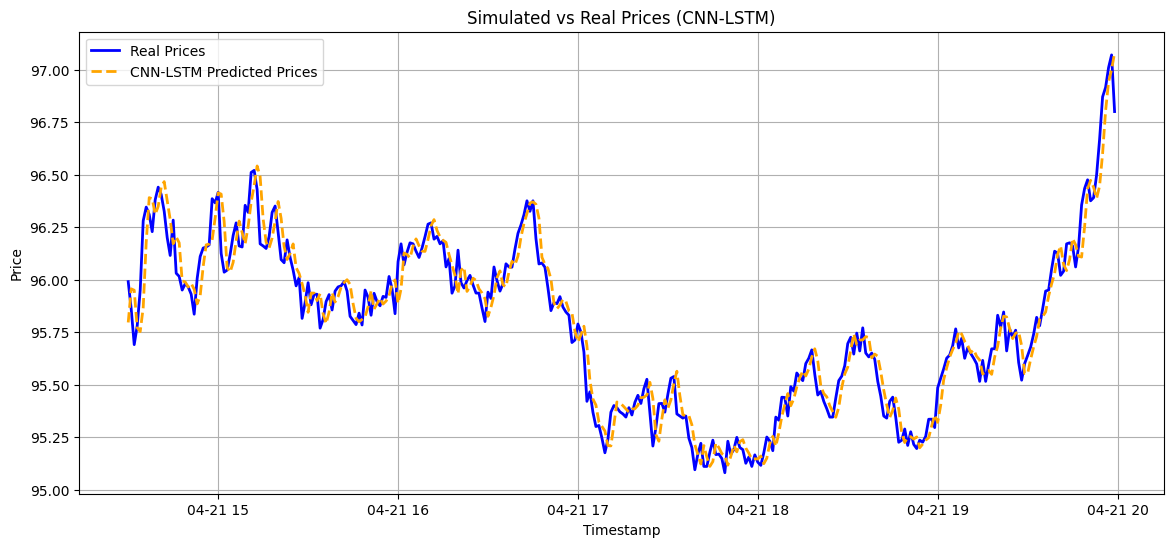

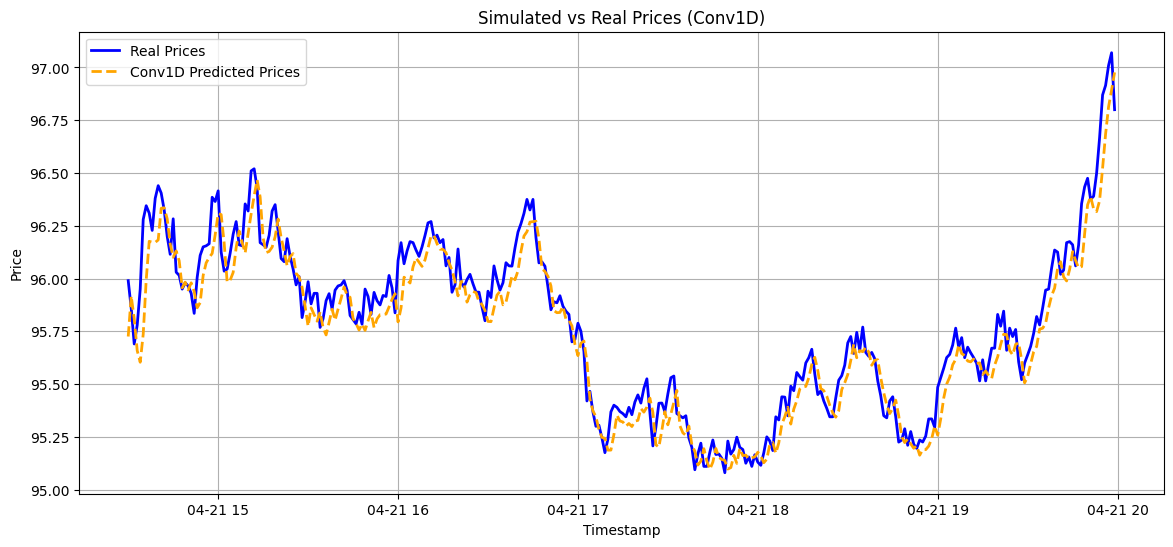

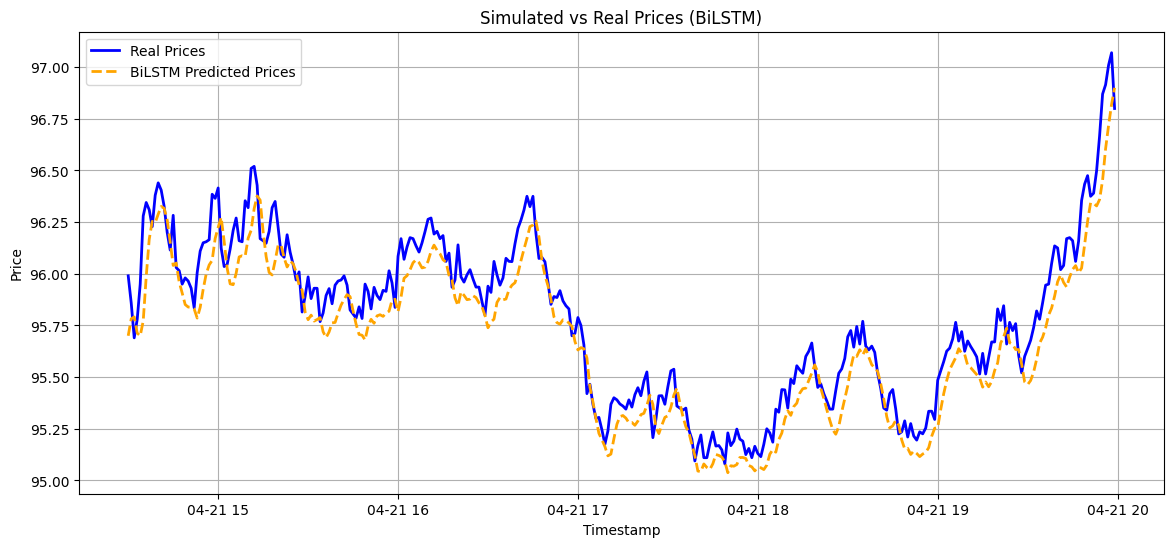

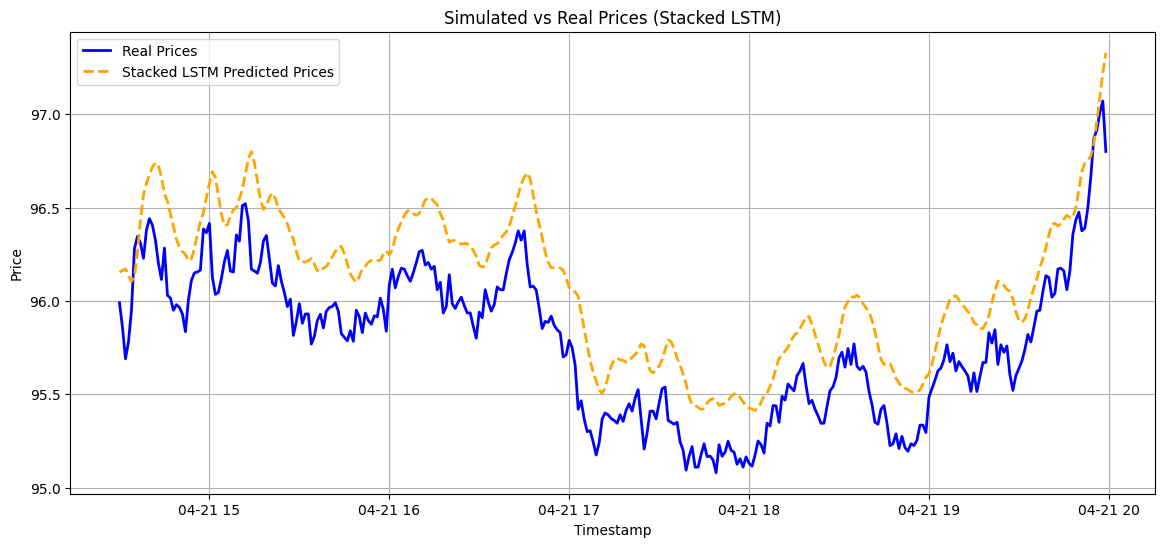

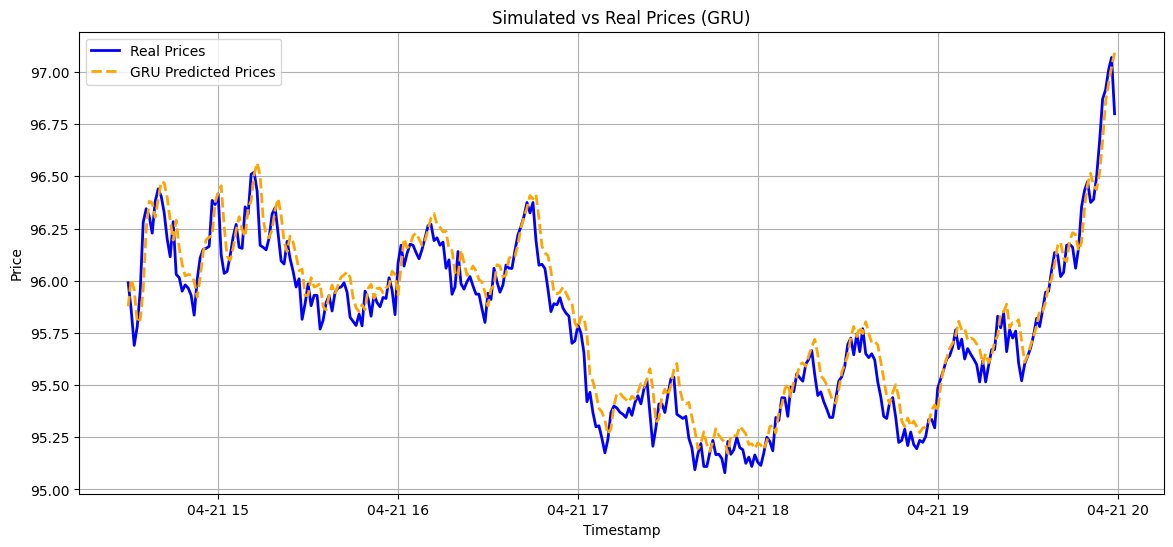

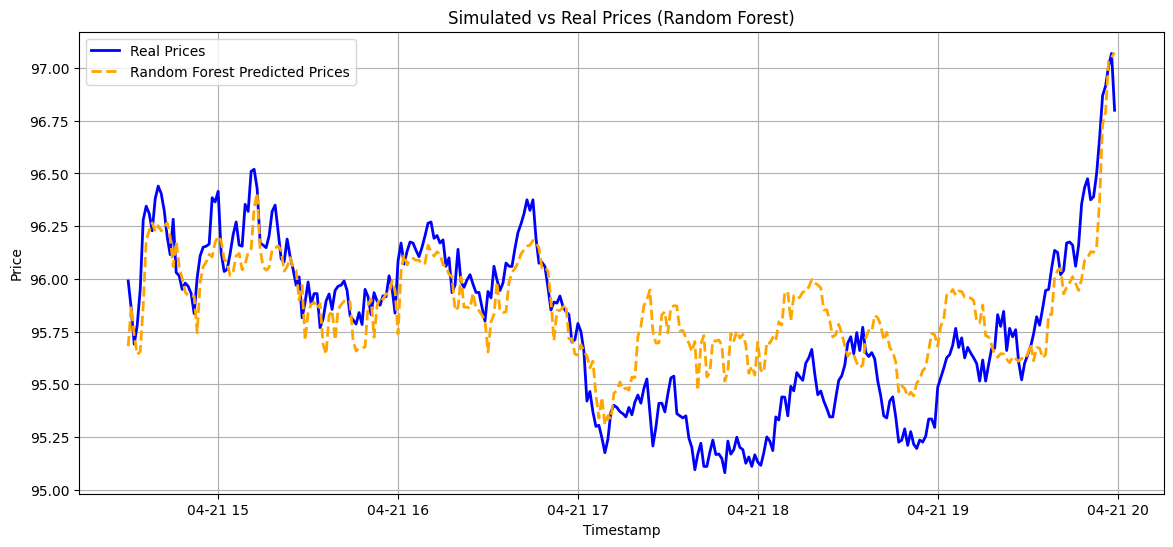

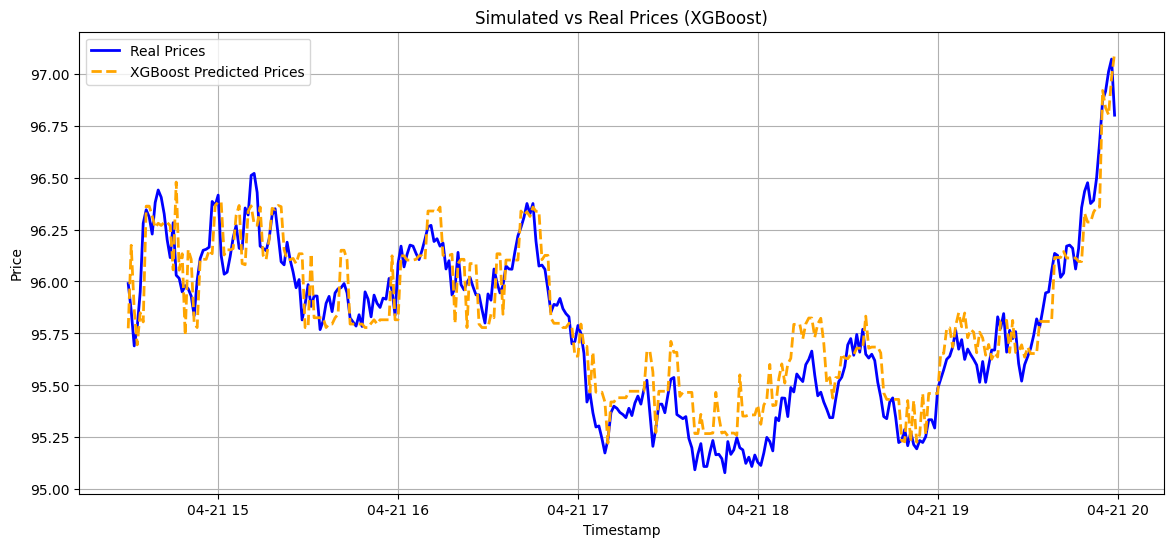

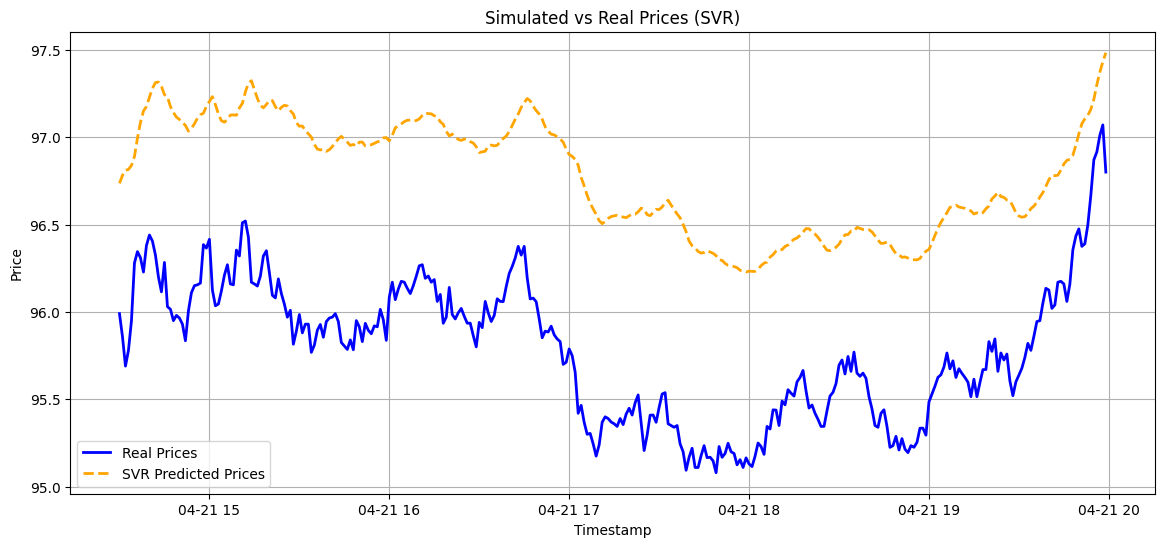

In [ ]:
import matplotlib.pyplot as plt

# Function to plot simulated line graphs
def plot_simulated_graph(model_name, predicted_prices, real_prices):
    # Ensure timestamps and data lengths match
    num_data_points = min(len(data_15th.index[SEQ_LENGTH:]), len(predicted_prices), len(real_prices))
    timestamps = data_15th.index[SEQ_LENGTH:SEQ_LENGTH + num_data_points]
    predicted_prices = predicted_prices[:num_data_points]
    real_prices = real_prices[:num_data_points]

    plt.figure(figsize=(14, 6))
    plt.plot(timestamps, real_prices, label="Real Prices", color="blue", linewidth=2)
    plt.plot(timestamps, predicted_prices, label=f"{model_name} Predicted Prices", linestyle="--", color="orange", linewidth=2)

    plt.title(f"Simulated vs Real Prices ({model_name})")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

# Plot simulated line graphs for all models
for model_name, data in results.items():
    predicted_prices = data["Predicted Prices"]
    real_prices = data["Real Prices"]
    plot_simulated_graph(model_name, predicted_prices, real_prices)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize an empty list to store similarity metrics
similarity_metrics = []

# Loop through each model in the results dictionary
for model_name, data in results.items():
    predicted_prices = data["Predicted Prices"]
    real_prices = data["Real Prices"]

    # Ensure predicted_prices and real_prices have the same length
    min_length = min(len(predicted_prices), len(real_prices))
    predicted_prices = predicted_prices[:min_length]
    real_prices = real_prices[:min_length]

    # Calculate similarity metrics
    mae = mean_absolute_error(real_prices, predicted_prices)
    rmse = np.sqrt(mean_squared_error(real_prices, predicted_prices))
    r2 = r2_score(real_prices, predicted_prices)

    # Append the results to the similarity metrics table
    similarity_metrics.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

# Convert the similarity metrics into a Pandas DataFrame
similarity_df = pd.DataFrame(similarity_metrics)

# Display the similarity metrics table
print("Similarity Metrics Table:")
print(similarity_df)

Similarity Metrics Table:
           Model       MAE      RMSE  R² Score
0       CNN-LSTM  0.078291  0.100261  0.936853
1         Conv1D  0.092207  0.116879  0.914186
2         BiLSTM  0.121103  0.145973  0.866145
3   Stacked LSTM  0.300462  0.320614  0.354269
4            GRU  0.086635  0.109588  0.924558
5  Random Forest  0.200819  0.253056  0.597728
6        XGBoost  0.119448  0.148464  0.861538
7            SVR  0.988895  1.006291 -5.361140


In [ ]:
# Find the best model based on lowest RMSE and highest R²
best_model_rmse = similarity_df.loc[similarity_df['RMSE'].idxmin()]
best_model_r2 = similarity_df.loc[similarity_df['R² Score'].idxmax()]

print("\nBest Model Based on RMSE:")
print(best_model_rmse)

print("\nBest Model Based on R² Score:")
print(best_model_r2)


Best Model Based on RMSE:
Model       CNN-LSTM
MAE         0.078291
RMSE        0.100261
R² Score    0.936853
Name: 0, dtype: object

Best Model Based on R² Score:
Model       CNN-LSTM
MAE         0.078291
RMSE        0.100261
R² Score    0.936853
Name: 0, dtype: object


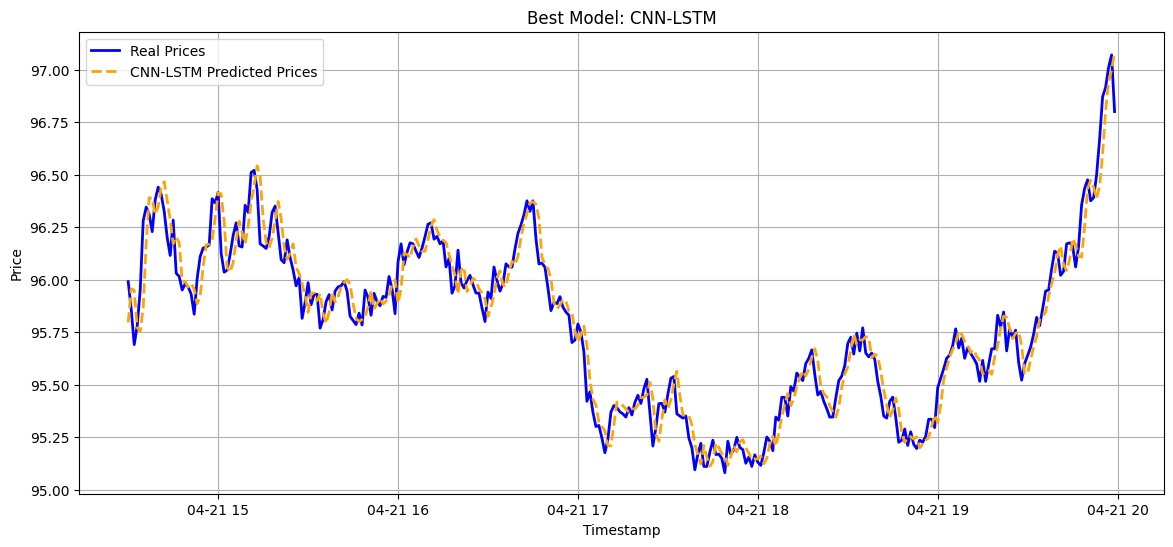

In [ ]:
# Extract the best model based on RMSE
best_model_name = best_model_rmse['Model']
best_model_data = results[best_model_name]
best_predicted_prices = best_model_data["Predicted Prices"]
best_real_prices = best_model_data["Real Prices"]

# Plot the best model's graph
timestamps = data_15th.index[SEQ_LENGTH:]

# Ensure predicted and real prices have the same length for plotting
min_length = min(len(timestamps), len(best_predicted_prices), len(best_real_prices))
timestamps = timestamps[:min_length]
best_predicted_prices = best_predicted_prices[:min_length]
best_real_prices = best_real_prices[:min_length]


plt.figure(figsize=(14, 6))
plt.plot(timestamps, best_real_prices, label="Real Prices", color="blue", linewidth=2)
plt.plot(timestamps, best_predicted_prices, label=f"{best_model_name} Predicted Prices", linestyle="--", color="orange", linewidth=2)

plt.title(f"Best Model: {best_model_name}")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Extract data for the best model
best_model_name = best_model_rmse['Model']  # Use the best model identified earlier
best_model_data = results[best_model_name]
predicted_prices = best_model_data["Predicted Prices"]
real_prices = best_model_data["Real Prices"]

# Find predicted lowest and highest prices and their timestamps
predicted_lowest_price = np.min(predicted_prices)
predicted_highest_price = np.max(predicted_prices)

predicted_lowest_timestamp = np.argmin(predicted_prices)
predicted_highest_timestamp = np.argmax(predicted_prices)

print(f"Predicted Lowest Price: {predicted_lowest_price:.2f} at Timestamp: {predicted_lowest_timestamp}")
print(f"Predicted Highest Price: {predicted_highest_price:.2f} at Timestamp: {predicted_highest_timestamp}")

Predicted Lowest Price: 95.11 at Timestamp: 194
Predicted Highest Price: 97.08 at Timestamp: 329


In [ ]:
# Extract real prices at the predicted timestamps
real_lowest_price = real_prices[predicted_lowest_timestamp]
real_highest_price = real_prices[predicted_highest_timestamp]

print(f"Real Price at Predicted Lowest Timestamp: {real_lowest_price:.2f}")
print(f"Real Price at Predicted Highest Timestamp: {real_highest_price:.2f}")

Real Price at Predicted Lowest Timestamp: 95.18
Real Price at Predicted Highest Timestamp: 96.80


In [ ]:
# Determine buy/sell signal based on timestamps
if predicted_highest_timestamp > predicted_lowest_timestamp:
    # Buy signal (long position)
    profit = real_highest_price - real_lowest_price
    signal = "Buy"
else:
    # Sell signal (short position)
    profit = real_highest_price - real_lowest_price
    signal = "Sell"

print(f"Signal: {signal}")
print(f"Profit: {profit:.2f}")

Signal: Buy
Profit: 1.62


In [ ]:
# Store trade opportunity details
trade_opportunity = {
    "Model": best_model_name,
    "Signal": signal,
    "Profit": profit,
    "Predicted Lowest Price": predicted_lowest_price,
    "Predicted Highest Price": predicted_highest_price,
    "Real Lowest Price": real_lowest_price,
    "Real Highest Price": real_highest_price
}

print("Trade Opportunity Details:")
for key, value in trade_opportunity.items():
    print(f"{key}: {value}")

Trade Opportunity Details:
Model: CNN-LSTM
Signal: Buy
Profit: 1.622802734375
Predicted Lowest Price: 95.11011505126953
Predicted Highest Price: 97.08026123046875
Real Lowest Price: 95.17720031738281
Real Highest Price: 96.80000305175781


In [ ]:
# Initialize variables to track the best trade opportunity
best_trade_opportunity = None
max_profit = float('-inf')

# Loop through each model in the results dictionary
for model_name, data in results.items():
    predicted_prices = data["Predicted Prices"]
    real_prices = data["Real Prices"]

    # Find predicted lowest and highest prices and their timestamps
    predicted_lowest_price = np.min(predicted_prices)
    predicted_highest_price = np.max(predicted_prices)
    predicted_lowest_timestamp = np.argmin(predicted_prices)
    predicted_highest_timestamp = np.argmax(predicted_prices)

    # Extract real prices at the predicted timestamps
    real_lowest_price = real_prices[predicted_lowest_timestamp]
    real_highest_price = real_prices[predicted_highest_timestamp]

    # Determine buy/sell signal and calculate profit
    if predicted_highest_timestamp > predicted_lowest_timestamp:
        profit = real_highest_price - real_lowest_price
        signal = "Buy"
    else:
        profit = real_highest_price - real_lowest_price
        signal = "Sell"

    # Update the best trade opportunity if this profit is higher
    if profit > max_profit:
        max_profit = profit
        best_trade_opportunity = {
            "Model": model_name,
            "Signal": signal,
            "Profit": profit,
            "Predicted Lowest Price": predicted_lowest_price,
            "Predicted Highest Price": predicted_highest_price,
            "Real Lowest Price": real_lowest_price,
            "Real Highest Price": real_highest_price
        }

# Print the best trade opportunity
print("\nBest Trade Opportunity:")
for key, value in best_trade_opportunity.items():
    print(f"{key}: {value}")


Best Trade Opportunity:
Model: SVR
Signal: Buy
Profit: 1.6350021362304688
Predicted Lowest Price: 96.22807228973262
Predicted Highest Price: 97.48283415785026
Real Lowest Price: 95.16500091552734
Real Highest Price: 96.80000305175781


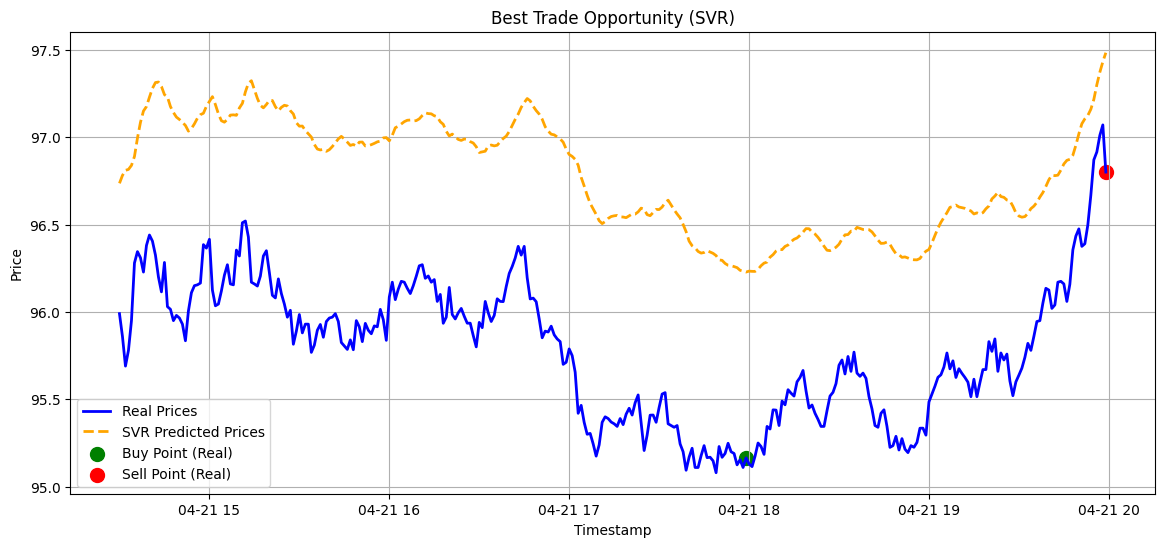

In [ ]:
# Extract details for the best trade opportunity
best_model_name = best_trade_opportunity["Model"]
best_signal = best_trade_opportunity["Signal"]
best_profit = best_trade_opportunity["Profit"]
predicted_lowest_price = best_trade_opportunity["Predicted Lowest Price"]
predicted_highest_price = best_trade_opportunity["Predicted Highest Price"]
real_lowest_price = best_trade_opportunity["Real Lowest Price"]
real_highest_price = best_trade_opportunity["Real Highest Price"]

# Extract timestamps for the best model
timestamps = data_15th.index[SEQ_LENGTH:]
best_predicted_prices = results[best_model_name]["Predicted Prices"]
best_real_prices = results[best_model_name]["Real Prices"]

# Ensure predicted and real prices have the same length for plotting
min_length = min(len(timestamps), len(best_predicted_prices), len(best_real_prices))
timestamps = timestamps[:min_length]
best_predicted_prices = best_predicted_prices[:min_length]
best_real_prices = best_real_prices[:min_length]


# Plot the graph
plt.figure(figsize=(14, 6))
plt.plot(timestamps, best_real_prices, label="Real Prices", color="blue", linewidth=2)
plt.plot(timestamps, best_predicted_prices, label=f"{best_model_name} Predicted Prices", linestyle="--", color="orange", linewidth=2)

# Highlight buy/sell points
if best_signal == "Buy":
    plt.scatter(
        timestamps[predicted_lowest_timestamp],
        real_lowest_price,
        label="Buy Point (Real)", color="green", s=100
    )
    plt.scatter(
        timestamps[predicted_highest_timestamp],
        real_highest_price,
        label="Sell Point (Real)", color="red", s=100
    )
else:
    plt.scatter(
        timestamps[predicted_highest_timestamp],
        real_highest_price,
        label="Sell Point (Real)", color="red", s=100
    )
    plt.scatter(
        timestamps[predicted_lowest_timestamp],
        real_lowest_price,
        label="Buy Point (Real)", color="green", s=100
    )

plt.title(f"Best Trade Opportunity ({best_model_name})")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

similarity_df_sorted = similarity_df.sort_values(by="R² Score", ascending=False) # Changed 'Ascending' to 'ascending'

top_n = 8
top_models = similarity_df_sorted["Model"].head(top_n).tolist()

all_model_predictions = {}

for model_name in top_models:
  if model_name in results:
    y_pred = results[model_name]["Predicted Prices"]
    y_test = results[model_name]["Real Prices"]

    min_len = min(len(y_pred), len(y_test))
    y_pred = y_pred[:min_len]
    y_test = y_test[:min_len]

    all_model_predictions[f"y_test_{model_name}"] = y_test
  else:
    print(f"\nWarnings: Results not found for model: {model_name}")

results_df = pd.DataFrame(all_model_predictions)

results_df.to_csv("all_model_predictions.csv", index=False)

print("\nAll model predictions saved to 'all_model_predictions.csv'")


All model predictions saved to 'all_model_predictions.csv'


In [ ]:
results_df

,y_test_CNN-LSTM,y_test_GRU,y_test_Conv1D,y_test_BiLSTM,y_test_XGBoost,y_test_Random Forest,y_test_Stacked LSTM,y_test_SVR
0,95.989998,95.989998,95.989998,95.989998,95.989998,95.989998,95.989998,95.989998
1,95.859001,95.859001,95.859001,95.859001,95.859001,95.859001,95.859001,95.859001
2,95.690002,95.690002,95.690002,95.690002,95.690002,95.690002,95.690002,95.690002
3,95.779999,95.779999,95.779999,95.779999,95.779999,95.779999,95.779999,95.779999
4,95.949997,95.949997,95.949997,95.949997,95.949997,95.949997,95.949997,95.949997
...,...,...,...,...,...,...,...,...
325,96.870003,96.870003,96.870003,96.870003,96.870003,96.870003,96.870003,96.870003
326,96.915001,96.915001,96.915001,96.915001,96.915001,96.915001,96.915001,96.915001
327,97.009903,97.009903,97.009903,97.009903,97.009903,97.009903,97.009903,97.009903
328,97.069901,97.069901,97.069901,97.069901,97.069901,97.069901,97.069901,97.069901


In [ ]:
# prompt: output results_df as csv file and download the file in computer

from google.colab import files
files.download('all_model_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>